In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import groupby
import math
import os
import pickle
from CADA.paths import MODEL_DIRECTORY

all_patients = os.path.join(MODEL_DIRECTORY, 'double_false', 'patient.xlsx')
patients_df = pd.read_excel(all_patients, header=0)
len(patients_df)

5178

In [20]:
patients_df.groupby('from_file').count()

,patient_id,omim,gene,features,submitter,num_features
from_file,,,,,,
clinvar,2752,2752,2752,2752,2752,2752
fm_benchmarking,45,45,45,45,45,45
genetikum,45,45,45,45,45,45
json_from_f2g,9,9,9,9,9,9
pedia,679,679,679,679,679,679
pki,45,45,45,45,45,45
tubingen,925,925,925,925,925,925
tucases,678,678,678,678,678,678


In [21]:
patient_dict = dict()
for i in patients_df.groupby('from_file').count().iterrows():
    patient_dict[i[0]] = i[1][0]

others = 0
labels = 'Clinvar', 'PEDIA', 'F2G and other collaborators'
values = []
colors = ['#ff9999','#66b3ff', '#ffcc99']
for key in patient_dict.keys():
    if key == 'clinvar':
        values.append(patient_dict[key])
    elif key == 'pedia':
        values.append(patient_dict[key])
    else:
        others += patient_dict[key]
values.append(others)

print(values)

[2752, 679, 1747]


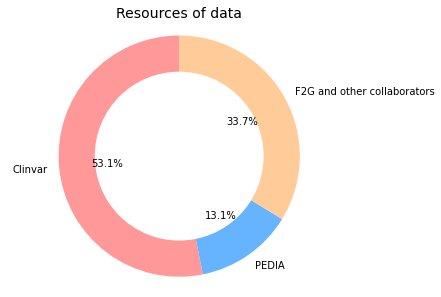

In [22]:
### Pie chart: Data coming from(Clinvar, PEDIA, Others)
fig1, ax1 = plt.subplots()
ax1.pie(values, colors = colors, labels=labels, autopct='%1.1f%%', startangle=90)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
ax1.axis('equal')  
plt.tight_layout()
plt.title("Resources of data", fontsize=14)
plt.savefig('graphs/patient_from_proportion.png', bbox_inches = 'tight')
plt.show()

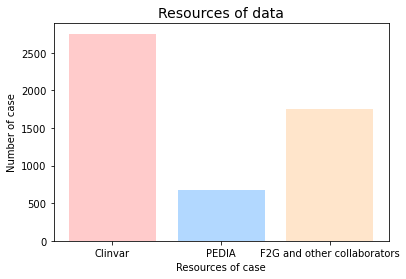

In [23]:
### Bar chart: Data coming from(Clinvar, PEDIA, Others)
labels = ['Clinvar', 'PEDIA', 'F2G and other collaborators']
y_pos = np.arange(len(labels))
plt.bar(y_pos, values, color=colors,align='center', alpha=0.5)
plt.xticks(y_pos, labels)
plt.ylabel('Number of case')
plt.xlabel("Resources of case")
plt.title("Resources of data", fontsize=14)
plt.savefig('graphs/patient_from_number.png')
plt.show()


In [24]:
### Table chart: Patient number annotation information()
p_with_both = len(patients_df[(patients_df['omim'] != 'unknown') & (patients_df['gene'] != 'unknown')])
p_with_both

2828

In [25]:
p_without_g = len(patients_df[(patients_df['gene'] == 'unknown')])
p_without_g

215

In [26]:
p_without_d = len(patients_df[(patients_df['omim'] == 'unknown')])
p_without_d

2135

In [27]:
p_with_none = len(patients_df[(patients_df['omim'] == 'unknown') & (patients_df['gene'] == 'unknown')])
p_with_none

0

In [28]:
p_with_both/(p_without_d + p_without_g + p_with_both)

0.5461568173039784

In [29]:
p_without_d/(p_without_d + p_without_g + p_with_both)

0.4123213595983005

In [30]:
p_without_g/(p_without_d + p_without_g + p_with_both)

0.04152182309772113

In [31]:
### total annotated disease number
disease_dict = dict()
for i in patients_df.groupby('omim').count().sort_values('patient_id', ascending=False)[1:].iterrows():
    disease_dict[i[0]] = i[1][0]
len(disease_dict.keys())


973

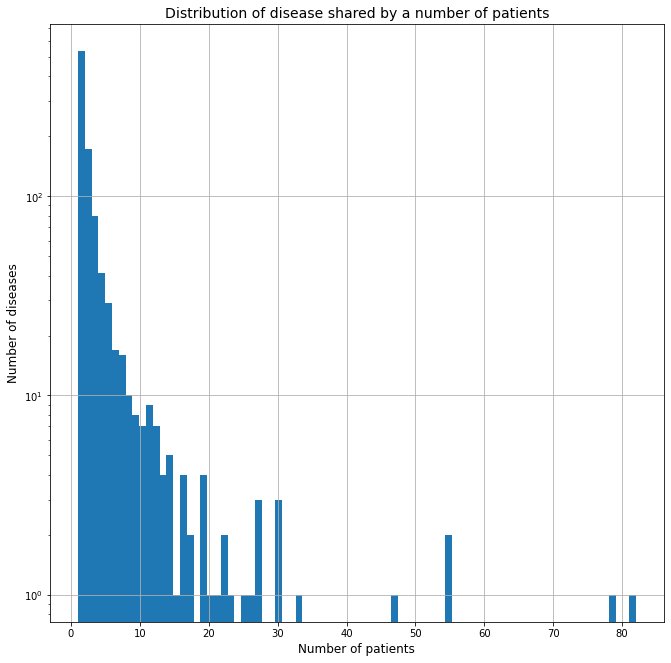

In [32]:
### Histogram: patient number(x) vs disease number(y)

n_patients = []    
for key in disease_dict:
    n_patients.append(disease_dict[key])

fig = plt.figure(figsize=(11,11))
plt.grid()
plt.title("Distribution of disease shared by a number of patients", fontsize=14)
_ = plt.hist(n_patients, bins=82)
plt.yscale('log', nonposy='clip')
plt.xlabel("Number of patients", fontsize=12)
plt.ylabel("Number of diseases", fontsize=12)
plt.savefig('graphs/distribution_of_disease_shared_by_a_number_of_patients.png')
plt.show()

['BLOOM SYNDROME', 'COFFIN-SIRIS SYNDROME 1', 'NOONAN SYNDROME 8', 'NOONAN SYNDROME 1', 'KBG SYNDROME', 'HYPERPHOSPHATASIA WITH MENTAL RETARDATION SYNDROME 1', 'SPASTIC PARAPLEGIA 4, AUTOSOMAL DOMINANT', 'SOTOS SYNDROME 1', 'RUBINSTEIN-TAYBI SYNDROME 1', 'CHROMOSOME 8q21.11 DELETION SYNDROME', 'CHARGE SYNDROME', 'HYPERPHOSPHATASIA WITH MENTAL RETARDATION SYNDROME 4']


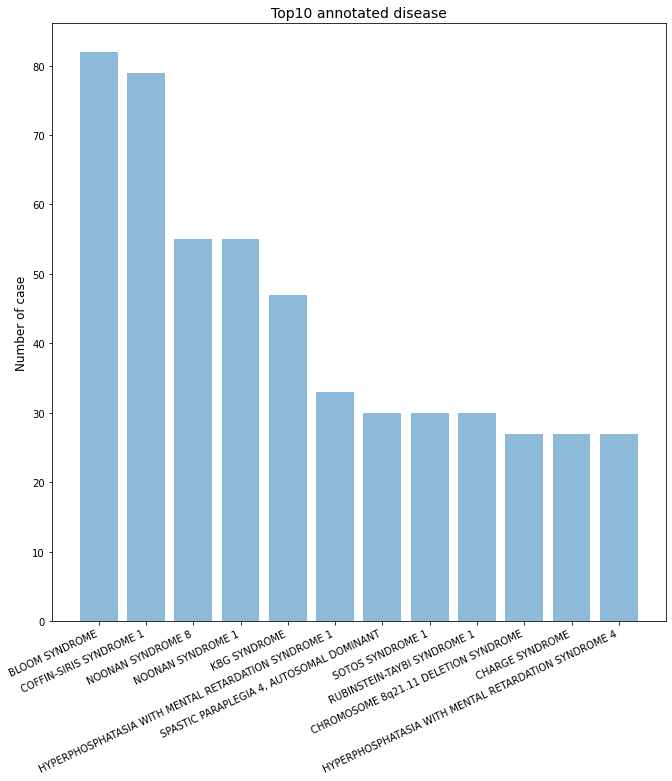

In [33]:
### Top 10 disease
labels = []
values = []
for index, key in enumerate(disease_dict):
    if index < 12:
        if ';' in key:
            labels.append(key.split(';')[0])
        else:
            labels.append(key)
        values.append(disease_dict[key])

print(labels)
y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 annotated disease", fontsize=14)
plt.bar(y_pos, values, align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of case', fontsize=12)
#plt.xlabel("Annoated disease", fontsize=12)
plt.savefig('graphs/top10_disease.png', bbox_inches = 'tight')
plt.show()

In [34]:
### total annotated gene number
gene_dict = dict()
for i in patients_df.groupby('gene').count().sort_values('patient_id', ascending=False)[1:].iterrows():
    gene_dict[i[0]] = i[1][0]

len(gene_dict.keys())

1472

In [37]:
### the number of gene having more than N cases
count1 = count2 = count3 = count5 = count10 = 0

for gene in gene_dict.keys():
    count = gene_dict[gene]
    if count == 1:
        count1 += 1
    if count >= 2:
        count2 += 1
    if count >= 3:
        count3 += 1
    if count >= 5:
        count5 += 1
    if count >= 10:
        count10 += 1

print("Genes that are annotated by only 1 patient: " , count1)
print("Genes that are annotated by more than 2 patients: " , count2)
print("Genes that are annotated by more than 3 patients: " , count3)
print("Genes that are annotated by more than 5 patients: " , count5)
print("Genes that are annotated by more than 10 patients: " , count10)
        


Genes that are annotated by only 1 patient:  768
Genes that are annotated by more than 2 patients:  704
Genes that are annotated by more than 3 patients:  435
Genes that are annotated by more than 5 patients:  227
Genes that are annotated by more than 10 patients:  107


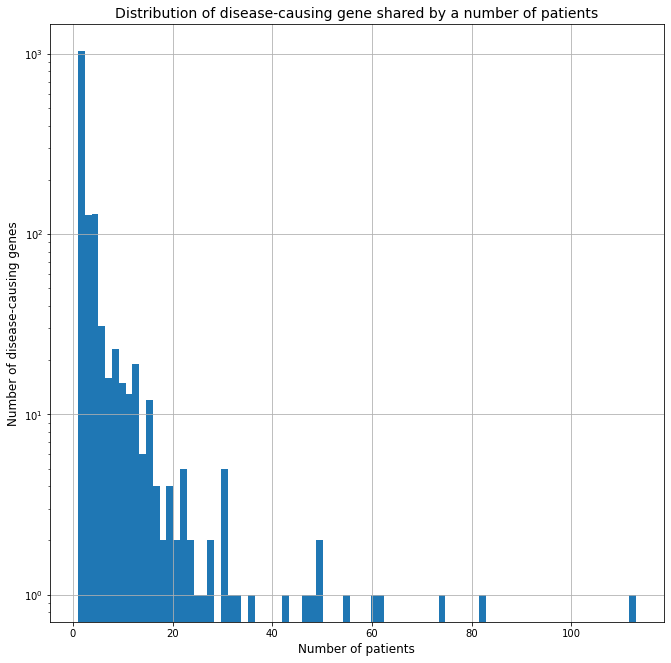

In [30]:
### Histogram: patinet number(x) vs gene number(y)
n_patients = []    
for key in gene_dict:
    n_patients.append(gene_dict[key])

fig = plt.figure(figsize=(11,11))
plt.title("Distribution of disease-causing gene shared by a number of patients", fontsize=14)
_ = plt.hist(n_patients, bins=82)
plt.yscale('log', nonposy='clip')
plt.xlabel("Number of patients", fontsize=12)
plt.ylabel("Number of disease-causing genes", fontsize=12)
plt.savefig('graphs/distribution_of_disease-causing_gene_shared_by_a_number_of_patients.png')
plt.grid()
plt.show()

['ABCC6', 'BLM', 'ARID1B', 'FBN1', 'BRCA1', 'RIT1', 'PTPN11', 'NF1', 'BRCA2', 'ANKRD11']


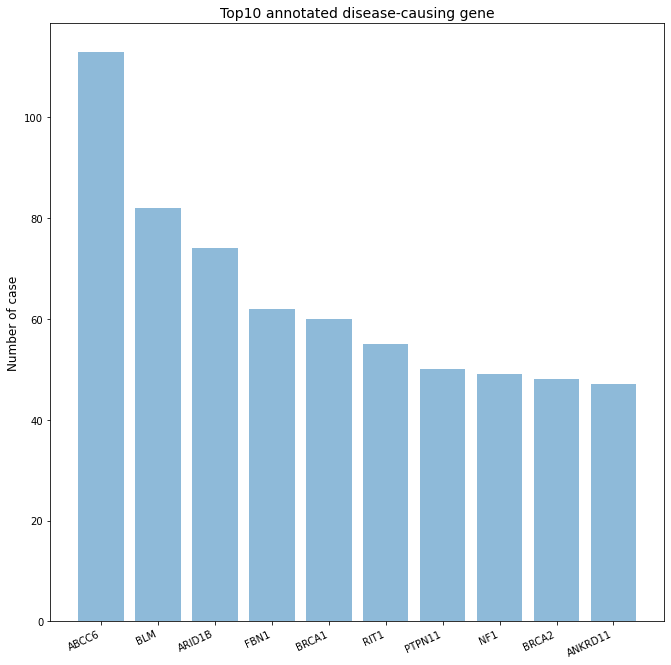

In [38]:
### Top 10 disease-causing gene
gene_dict = dict()
for i in patients_df.groupby('gene').count().sort_values('patient_id', ascending=False)[1:].iterrows():
    gene_dict[i[0]] = i[1][0]

labels = []
values = []
for index, key in enumerate(gene_dict):
    if index < 10:
        labels.append(key)
        values.append(gene_dict[key])

print(labels)
y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 annotated disease-causing gene", fontsize=14)
plt.bar(y_pos, values, align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of case', fontsize=12)
#plt.xlabel("Annotated disease-causing gene", fontsize=12)
plt.savefig('graphs/top10_gene.png')
plt.show()

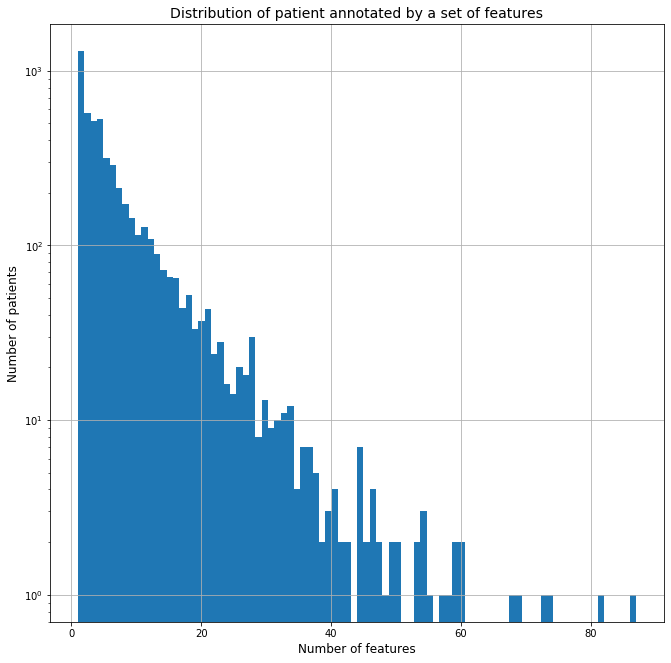

In [222]:
### Histogram: patinet number(x) vs gene number(y)
patients_list = patients_df.values.tolist()
n_features = []
for patient in patients_list:
    id = patient[0]
    n = len(patient[3].split(','))
    n_features.append(n)
    
    
fig = plt.figure(figsize=(11,11))
_ = plt.hist(n_features, bins=88)
plt.title("Distribution of patient annotated by a set of features", fontsize=14)

plt.yscale('log', nonposy='clip')
plt.xlabel("Number of features", fontsize=12)
plt.ylabel("Number of patients", fontsize=12)
plt.grid()
plt.savefig('graphs/distribution_of_patient_annotated_by_a_set_of_features.png')
plt.show()

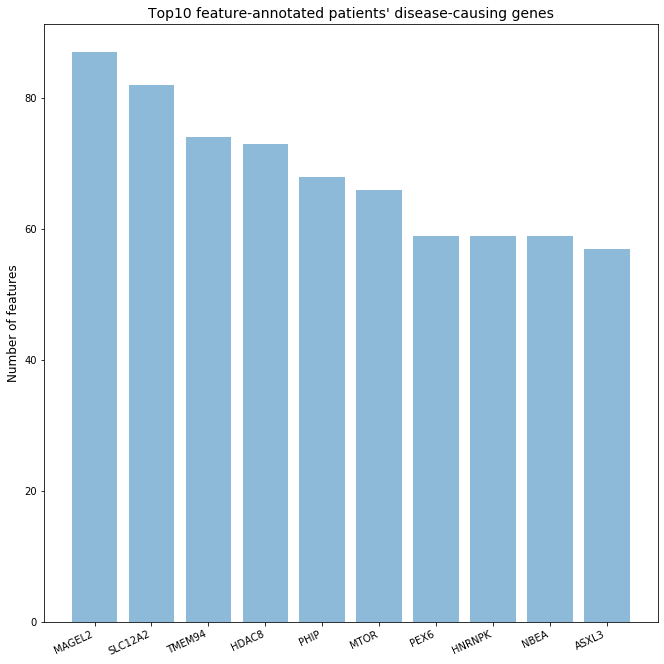

In [225]:
### Top10 feature annotated patients
labels = []
values = []

for patient in patients_df.sort_values('num_features', ascending = False).values.tolist()[:10]:
    labels.append(patient[2])
    values.append(patient[6])


y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 feature-annotated patients' disease-causing genes", fontsize=14)
plt.bar(y_pos, values, align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of features', fontsize=12)
#plt.xlabel("Annotated disease-causing gene", fontsize=12)
plt.savefig('graphs/top10_annotated_patient.png')
plt.show()

In [226]:
import os
from CADA.paths import DATA_DIRECTORY
import pandas as pd

in_file = os.path.join(DATA_DIRECTORY, 'raw', 'hpo', 'gene-hpo', 'ALL_SOURCES_ALL_FREQUENCIES_genes_to_phenotype.txt')

df = pd.read_csv(in_file, skiprows=1, header=None, sep ='\t').applymap(str)
df.iloc[:, 0] = 'Entrez:' + df.iloc[:, 0]
gene_features = {}
for row in df.values.tolist():
    gene = row[0].strip()
    feature = row[3].strip()
    if gene not in gene_features:
        gene_features[gene] = []
        gene_features[gene].append(feature)
    else:
        gene_features[gene].append(feature)

gene_features
        


{'Entrez:8192': ['HP:0004322',
  'HP:0001250',
  'HP:0000786',
  'HP:0000007',
  'HP:0000252',
  'HP:0000013',
  'HP:0000815',
  'HP:0008527'],
 'Entrez:2': ['HP:0410054',
  'HP:0001425',
  'HP:0001300',
  'HP:0000006',
  'HP:0000726',
  'HP:0002423',
  'HP:0002185',
  'HP:0002511'],
 'Entrez:8195': ['HP:0000512',
  'HP:0003202',
  'HP:0000003',
  'HP:0001156',
  'HP:0000007',
  'HP:0001159',
  'HP:0000135',
  'HP:0001162',
  'HP:0001163',
  'HP:0006159',
  'HP:0000143',
  'HP:0000145',
  'HP:0000148',
  'HP:0008724',
  'HP:0000028',
  'HP:0004383',
  'HP:0008736',
  'HP:0001830',
  'HP:0000807',
  'HP:0002089',
  'HP:0003241',
  'HP:0100779',
  'HP:0000426',
  'HP:0004397',
  'HP:0000175',
  'HP:0000047',
  'HP:0008368',
  'HP:0001586',
  'HP:0000819',
  'HP:0000822',
  'HP:0002230',
  'HP:0030010',
  'HP:0012227',
  'HP:0000580',
  'HP:0000072',
  'HP:0000969',
  'HP:0010442',
  'HP:0002251',
  'HP:0006101',
  'HP:0000470',
  'HP:0030680',
  'HP:0000218',
  'HP:0001629',
  'HP:000137

In [227]:
### Numer of features per gene
gene_n_features = []
gene_n_features_list = []

with open(os.path.join(DATA_DIRECTORY, 'processed', 'ids', 'gene_id_name.dict'), 'rb') as handle:
    gene_id_name = pickle.load(handle)
    
for key in gene_features.keys():
    gene_n_features.append([key, gene_id_name[key], len(gene_features[key])])
    gene_n_features_list.append(len(gene_features[key]))


gene_df = pd.DataFrame(gene_n_features, columns=['Gene_id','Gene_symbol', 'num_features'])    

gene_df = gene_df.sort_values('num_features', ascending = False)
gene_df.to_excel('graphs/num_features_per_gene.xlsx', index = None)


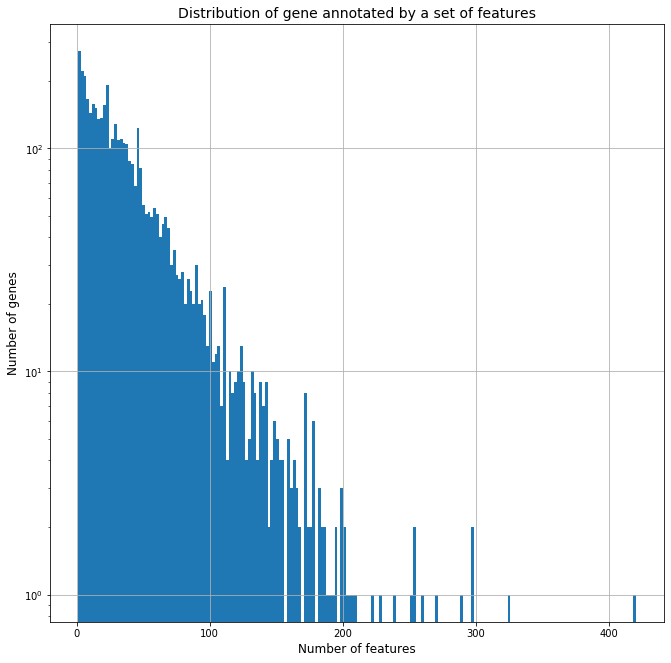

In [228]:
### Histogram: feature number(x) vs gene number(y)
fig = plt.figure(figsize=(11,11))
_ = plt.hist(gene_n_features_list, bins=200)
plt.title("Distribution of gene annotated by a set of features", fontsize=14)
plt.yscale('log', nonposy='clip')
plt.xlabel("Number of features", fontsize=12)
plt.ylabel("Number of genes", fontsize=12)
plt.grid()
plt.savefig('graphs/distribution_of_gene_annotated_by_a_set_of_features.png')
plt.show()

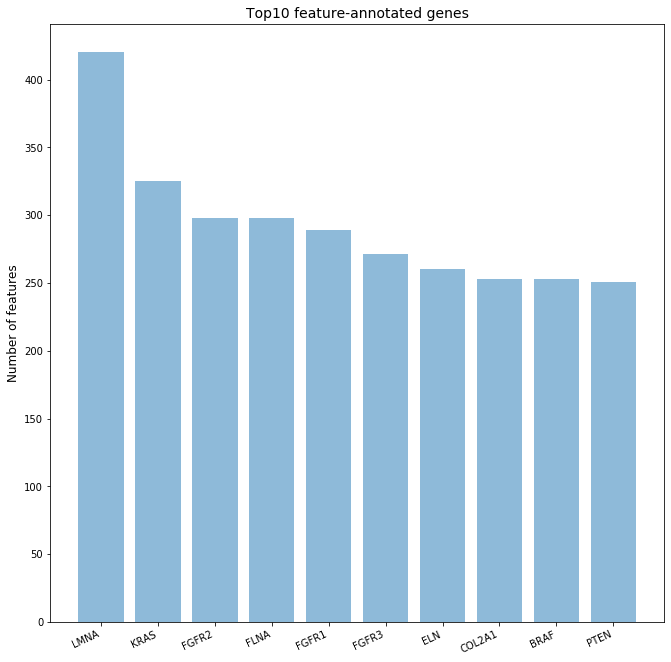

In [229]:
### Top 10 feature annotated gene
labels = []
values = []

for gene in gene_df.sort_values('num_features', ascending = False).values.tolist()[:10]:
    labels.append(gene[1])
    values.append(gene[2])


y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 feature-annotated genes", fontsize=14)
plt.bar(y_pos, values, align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of features', fontsize=12)
#plt.xlabel("Annotated disease-causing gene", fontsize=12)
plt.savefig('graphs/top10_annotated_gene.png')
plt.show()
    